# 04 — Residuos: municipios que rompen su tendencia
## Fase 4 del TFM: Análisis del comportamiento electoral territorial en Colombia

Este notebook calcula, para cada municipio y elección, la diferencia entre el voto de izquierda
**real** y el que predice el modelo entrenado con su propia trayectoria histórica (modelo Ridge
con lag, elegido en Fase 3). A esa diferencia la llamamos **residuo**.

**Qué significa un residuo alto — y qué no significa.** Un municipio con residuo alto en 2022 votó
significativamente distinto de lo que su propia historia y su perfil estructural predecían. Eso es
una señal de **cambio político genuino** que merece mirarse con más detalle — no es, y este punto es
central para todo lo que sigue, una prueba de irregularidad electoral.

Esta distinción no es una precaución retórica: es el resultado directo de un hallazgo de la Fase 3.
El diseño original del proyecto planteaba que estos residuos revelarían posible coacción electoral
en zonas de conflicto armado. Esa hipótesis se puso a prueba con dos experimentos sucesivos: el
primero sí mostró una brecha entre zonas de conflicto y el resto; el segundo, controlando por
pobreza (NBI) y región, demostró que esa brecha se desplomaba a menos de 2 puntos y que `per_ocu`
(intensidad del conflicto armado) no aporta nada por encima de NBI+región. La hipótesis de coacción
se descartó con evidencia. Por eso, en todo este notebook, un residuo alto se interpreta como
*"este municipio se desvió de su propia tendencia"* — nunca como *"este municipio fue coaccionado"*.

**Lo que produce este notebook:**
1. La tabla de residuos (una fila por municipio-año, 2010/2014/2018/2022), calculada
   estrictamente *out-of-sample* — el residuo de cada año sale del modelo entrenado sin haber
   visto ese año, con la misma ventana expansiva de Fase 3.
2. Cuatro verificaciones explícitas antes de guardar nada: que 2006 no tenga residuos, que 2010
   quede marcado como ventana inestable, que cada residuo sea realmente out-of-sample, y que las
   banderas de confiabilidad estén bien heredadas.
3. `datos/procesados/tabla_residuos.csv` — el artefacto que consumirán tanto la memoria como la
   app Streamlit (Chat 7), sin que ninguno de los dos tenga que recalcular nada.
4. Un mapa y una tabla top-20 de los municipios que más se desvían en 2022, con los
   micro-electorados (`baja_confiabilidad_electoral=1`) excluidos del ranking — un municipio con
   4 votos no compite por el podio de anomalías.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import modelo as m

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)

BASE_DIR = '..'  # configurable, sin rutas locales hardcodeadas

In [2]:
df = pd.read_csv(f'{BASE_DIR}/datos/procesados/dataset_maestro_electoral.csv', dtype={'divipola': str})
df['divipola'] = df['divipola'].str.zfill(5)  # mismo principio de todo el proyecto: nunca asumir formato
print('Dataset maestro:', df.shape)
assert df.shape == (5605, 23), 'El dataset maestro no tiene la forma esperada (5605x23) - revisar antes de continuar'

df = df[df['valido_para_modelado'] == 1].copy()
print('Filas tras filtrar valido_para_modelado==1:', len(df))

geo = gpd.read_file(f'{BASE_DIR}/datos/geo/municipios_colombia_simplificado.geojson')
geo['divipola'] = geo['divipola'].astype(str).str.zfill(5)
print('Geometria municipal:', geo.shape, '| CRS:', geo.crs)
assert len(geo) == 1122, 'La geometria no tiene los 1.122 municipios esperados - revisar Fase 4 previa'

Dataset maestro: (5605, 23)
Filas tras filtrar valido_para_modelado==1: 5604


Geometria municipal: (1122, 2) | CRS: EPSG:4326


## 1. Cálculo de los residuos

La construcción de la tabla de residuos es lógica reutilizable: la necesitará también la app
Streamlit (Chat 7) para las páginas 2 y 3, y no queremos dos versiones de los residuos circulando
por el proyecto. Por eso vive en `src/modelo.py` (función `calcular_tabla_residuos`), no aquí
inline — este notebook la llama e interpreta el resultado, no reimplementa la lógica.

**El detalle que hace correcto el cálculo, y que conviene explicar antes de ejecutarlo**: para
cada año de test (2010, 2014, 2018, 2022) se entrena un **modelo nuevo**, exclusivamente con años
anteriores a ese año — la misma ventana expansiva de Fase 3. El residuo de 2014 sale del modelo
entrenado con 2006-2010; el de 2018, del entrenado con 2006-2014; el de 2022, del entrenado con
2006-2018. Son **cuatro modelos distintos**, no uno solo aplicado a los cuatro años — si se hiciera
con un modelo único entrenado con la ventana más amplia, los residuos de 2014 y 2018 saldrían
*in-sample* (el modelo ya habría visto esos años al entrenar) y parecerían razonables sin serlo,
rompiendo la regla out-of-sample de forma silenciosa. La función guarda, junto a cada residuo, el
rango de años con el que se entrenó su modelo (`anio_train_min`, `anio_train_max`), precisamente
para poder verificar esto de forma explícita más abajo (verificación 3).

In [3]:
tabla_residuos = m.calcular_tabla_residuos(df, m.COLUMNAS_PREDICTORAS_LAG)
print('Tabla de residuos:', tabla_residuos.shape)
tabla_residuos.head()

Tabla de residuos: (4487, 18)


,divipola,municipio,departamento,region_dane,ano,pct_izquierda,pct_izquierda_predicho,residuo,lag_pct_izquierda,nbi_total,per_ocu,baja_confiabilidad_electoral,peso_muestral,votos_totales_emitidos,ventana_estable,anio_train_min,anio_train_max,residuo_centrado
0,05001,MEDELLIN,ANTIOQUIA,Andina,2010,4.026878,30.775926,-26.749049,18.470992,12.424090,53294.0,0,1.0,737496.0,False,2006,2006,NaN
1,05002,ABEJORRAL,ANTIOQUIA,Andina,2010,1.026895,20.871146,-19.844251,6.190569,33.851120,53294.0,0,1.0,6297.0,False,2006,2006,NaN
2,05004,ABRIAQUI,ANTIOQUIA,Andina,2010,1.264223,25.830508,-24.566286,12.063953,28.538283,53294.0,0,1.0,813.0,False,2006,2006,NaN
3,05021,ALEJANDRIA,ANTIOQUIA,Andina,2010,0.732394,21.255635,-20.523240,6.730116,33.136095,53294.0,0,1.0,1812.0,False,2006,2006,NaN
4,05030,AMAGA,ANTIOQUIA,Andina,2010,2.353372,35.460560,-33.107188,23.121207,27.069045,53294.0,0,1.0,8551.0,False,2006,2006,NaN


## 2. Cuatro verificaciones, antes de guardar nada

Ninguna cifra ni artefacto se da por bueno sin verificarlo contra los datos reales primero — regla
de oro de este proyecto desde la Fase 1. Antes de guardar la tabla de residuos, se comprueban
explícitamente las cuatro cosas que tienen que cumplirse para que el mapa y la tabla top-20 que
vienen después sean honestos:

1. **2006 no tiene fila de residuo.** Es el primer año de la serie objetivo — nunca es año de test
   de ninguna ventana, solo aporta el lag. Si apareciera, sería la señal de un residuo in-sample
   colado por error.
2. **2010 aparece, pero marcado `ventana_estable=False`.** No se descarta — se marca, para que
   quien use la tabla decida con conocimiento de causa. Se marca porque la ventana que lo predice
   se entrena con una sola elección (2006) y es estructuralmente débil (Fase 3: R²≈-26 en esa
   ventana), no porque 2010 sea "un año malo" en sí.
3. **Cada residuo es realmente out-of-sample.** Se comprueba, año por año, que el modelo que generó
   ese bloque de residuos se entrenó exclusivamente con años estrictamente anteriores al propio año
   de test — nunca con el año que predice.
4. **Las banderas de confiabilidad están bien heredadas**, sin nulos y coherentes con el dataset
   maestro — son las que permiten, más abajo, excluir los micro-electorados del ranking de
   anomalías.

In [4]:
# Verificacion 1: 2006 no tiene fila de residuo
anios_presentes = sorted(tabla_residuos['ano'].unique())
print('Verificacion 1 - años presentes en la tabla:', anios_presentes)
assert 2006 not in anios_presentes, 'ERROR: 2006 no deberia tener residuo (no es año de test de ninguna ventana)'
assert anios_presentes == [2010, 2014, 2018, 2022], 'ERROR: la tabla no cubre exactamente los 4 años de test esperados'
print('OK: 2006 ausente, tabla cubre exactamente 2010/2014/2018/2022.')
print()

# Verificacion 2: 2010 marcado ventana_estable=False
ventana_2010_ok = (tabla_residuos.loc[tabla_residuos['ano'] == 2010, 'ventana_estable'] == False).all()
print('Verificacion 2 - 2010 marcado como ventana_estable=False:', ventana_2010_ok)
assert ventana_2010_ok, 'ERROR: 2010 deberia estar marcado como ventana inestable'
ventanas_estables_ok = (tabla_residuos.loc[tabla_residuos['ano'] != 2010, 'ventana_estable'] == True).all()
assert ventanas_estables_ok, 'ERROR: 2014/2018/2022 deberian estar marcados como ventana_estable=True'
print('OK: solo 2010 marcado inestable; 2014/2018/2022 marcados estables.')
print()

# Verificacion 3: cada residuo es out-of-sample - el rango de entrenamiento
# de cada año NUNCA incluye el propio año de test
print('Verificacion 3 - rango de entrenamiento del modelo que genero cada bloque de residuos:')
rango_train = tabla_residuos.groupby('ano')[['anio_train_min', 'anio_train_max']].first()
print(rango_train)
for ano_test, fila in rango_train.iterrows():
    assert fila['anio_train_max'] < ano_test, (
        f'ERROR: el modelo de {ano_test} se entreno hasta {fila["anio_train_max"]} '
        f'- deberia ser estrictamente anterior a {ano_test} (in-sample detectado)'
    )
print('OK: en los 4 años, anio_train_max < año de test - ningun modelo vio su propio año de test.')
print()

# Verificacion 4: banderas de confiabilidad sin nulos, coherentes con el dataset maestro
banderas = ['baja_confiabilidad_electoral', 'peso_muestral', 'votos_totales_emitidos']
nulos = tabla_residuos[banderas].isna().sum()
print('Verificacion 4 - nulos en banderas de confiabilidad:')
print(nulos)
assert nulos.sum() == 0, 'ERROR: hay nulos en las banderas de confiabilidad'

# Coherencia contra el dataset maestro: mismo valor de baja_confiabilidad_electoral
# para el mismo (divipola, ano) en ambas tablas
control = df[['divipola', 'ano'] + banderas].merge(
    tabla_residuos[['divipola', 'ano'] + banderas],
    on=['divipola', 'ano'], suffixes=('_maestro', '_residuos'), how='inner'
)
for col in banderas:
    coincide = (control[f'{col}_maestro'] == control[f'{col}_residuos']).all()
    assert coincide, f'ERROR: {col} no coincide entre el dataset maestro y la tabla de residuos'
print(f'OK: {len(control)} filas cruzadas contra el dataset maestro, banderas idénticas en las tres.')
print()
print('=' * 70)
print('LAS CUATRO VERIFICACIONES PASARON. La tabla de residuos es segura para guardar.')
print('=' * 70)

Verificacion 1 - años presentes en la tabla: [np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
OK: 2006 ausente, tabla cubre exactamente 2010/2014/2018/2022.

Verificacion 2 - 2010 marcado como ventana_estable=False: True
OK: solo 2010 marcado inestable; 2014/2018/2022 marcados estables.

Verificacion 3 - rango de entrenamiento del modelo que genero cada bloque de residuos:
      anio_train_min  anio_train_max
ano                                 
2010            2006            2006
2014            2006            2010
2018            2006            2014
2022            2006            2018
OK: en los 4 años, anio_train_max < año de test - ningun modelo vio su propio año de test.

Verificacion 4 - nulos en banderas de confiabilidad:
baja_confiabilidad_electoral    0
peso_muestral                   0
votos_totales_emitidos          0
dtype: int64
OK: 4487 filas cruzadas contra el dataset maestro, banderas idénticas en las tres.

LAS CUATRO VERIFICACIONES PASARON. La tabl

In [5]:
ruta_salida = f'{BASE_DIR}/datos/procesados/tabla_residuos.csv'
tabla_residuos.to_csv(ruta_salida, index=False)
print(f'Guardado: {ruta_salida} ({len(tabla_residuos)} filas, {tabla_residuos.shape[1]} columnas)')
print()
print('La app Streamlit (Chat 7) debe LEER este fichero directamente, nunca recalcular los residuos.')

Guardado: ../datos/procesados/tabla_residuos.csv (4487 filas, 18 columnas)

La app Streamlit (Chat 7) debe LEER este fichero directamente, nunca recalcular los residuos.


## 3. Distribución de los residuos por año

Antes de construir el mapa y el top-20 de 2022, conviene ver la forma general de los residuos en
las cuatro ventanas — incluida 2010, para que la inestabilidad de esa ventana (ya verificada
arriba) se vea también de forma visual, no solo en el flag.

/tmp/ipykernel_560/189763643.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_anio, labels=orden_anios, patch_artist=True)


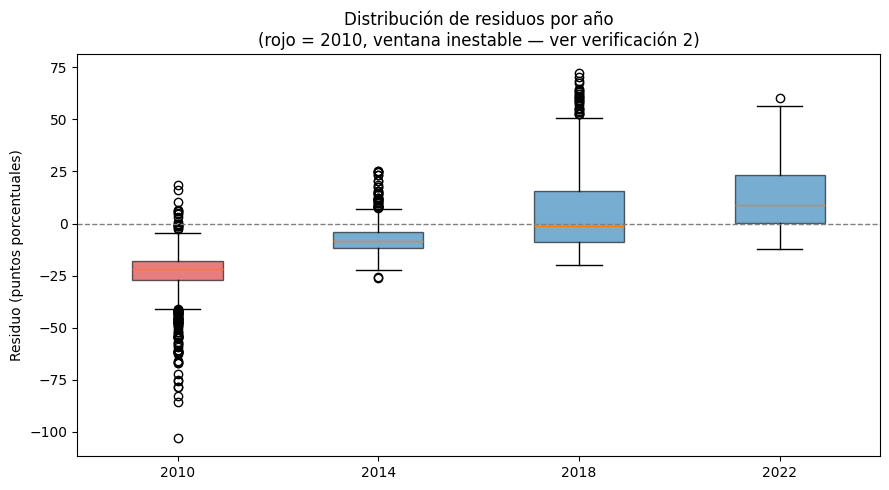

           mean        std         min        max
ano                                              
2010 -24.150110  11.216913 -102.905456  18.609039
2014  -7.305985   7.024382  -26.145742  25.399191
2018   4.613272  18.404383  -20.041692  72.503056
2022  12.556458  15.559724  -12.330554  60.498922


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
orden_anios = [2010, 2014, 2018, 2022]
datos_por_anio = [tabla_residuos.loc[tabla_residuos['ano'] == a, 'residuo'] for a in orden_anios]
colores = ['#d62728' if a == 2010 else '#1f77b4' for a in orden_anios]
bp = ax.boxplot(datos_por_anio, labels=orden_anios, patch_artist=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Residuo (puntos porcentuales)')
ax.set_title('Distribución de residuos por año\n(rojo = 2010, ventana inestable — ver verificación 2)')
plt.tight_layout()
plt.show()

print(tabla_residuos.groupby('ano')['residuo'].describe()[['mean', 'std', 'min', 'max']])

## 4. Top 20 — municipios que más rompen su tendencia (2022)

Se filtra `baja_confiabilidad_electoral == 0` **antes** de ordenar, no después — un municipio con
menos de 30 votos totales no debe competir por el podio de anomalías (ver nota introductoria: el
mismo principio que impide que un micro-electorado como Morichal salga como "el municipio más
anómalo del país" solo por el ruido estadístico de tener pocos votos).

In [7]:
t2022 = tabla_residuos[tabla_residuos['ano'] == 2022].copy()
t2022_confiable = t2022[t2022['baja_confiabilidad_electoral'] == 0].copy()
print(f'Municipios en 2022: {len(t2022)} | tras excluir baja confiabilidad: {len(t2022_confiable)} '
      f'({len(t2022) - len(t2022_confiable)} excluidos)')

top20 = t2022_confiable.reindex(
    t2022_confiable['residuo'].abs().sort_values(ascending=False).index
).head(20)

top20_mostrar = top20[[
    'municipio', 'departamento', 'region_dane', 'residuo',
    'pct_izquierda', 'pct_izquierda_predicho', 'nbi_total', 'per_ocu'
]].round(2)
top20_mostrar

Municipios en 2022: 1121 | tras excluir baja confiabilidad: 1119 (2 excluidos)


,municipio,departamento,region_dane,residuo,pct_izquierda,pct_izquierda_predicho,nbi_total,per_ocu
3748,TIMBIQUI,CAUCA,Pacifica,60.50,96.21,35.71,64.13,34383.0
3927,ALTO BAUDO,CHOCO,Pacifica,56.66,95.32,38.66,77.85,51998.0
3941,MEDIO BAUDO,CHOCO,Pacifica,56.25,82.12,25.87,63.21,51998.0
3930,BAJO BAUDO,CHOCO,Pacifica,54.84,83.39,28.55,65.87,51998.0
3728,LOPEZ DE MICAY,CAUCA,Pacifica,53.04,85.09,32.05,42.77,34383.0
4480,PACOA,VAUPES,Amazonia,51.54,81.86,30.32,93.65,60.0
3939,JURADO,CHOCO,Pacifica,50.63,81.50,30.87,56.11,51998.0
3723,GUACHENE,CAUCA,Pacifica,50.46,81.59,31.14,4.95,34383.0
3740,SAN SEBASTIAN,CAUCA,Pacifica,49.09,76.16,27.06,15.84,34383.0
3932,MEDIO ATRATO,CHOCO,Pacifica,48.98,81.07,32.09,51.64,51998.0


## 5. Mapas de municipios que rompen su tendencia (2022)

Dos mapas que van juntos, en este orden, tanto aquí como en la memoria y en la Página 3 de la app —
uno explica al otro, no se presentan por separado:

1. **Mapa absoluto (contexto, primero)**: muestra sobre todo la ola nacional de 2022, no un
   hallazgo territorial en sí.
2. **Mapa centrado (hallazgo principal, después)**: descuenta esa ola y muestra el patrón
   territorial real — es la figura de referencia.

Mapas estáticos para este notebook y para la memoria — el mapa **interactivo** de la app Streamlit
(Chat 7) usará `plotly` o `folium` embebido, no `geopandas`/`matplotlib`; queda anotado como
decisión pendiente para ese chat, no se resuelve aquí (Fase 4, revisión del chat maestro).

Igual que en el top-20, los municipios de baja confiabilidad se excluyen del cómputo de color (se
dibujan en gris neutro). San Andrés y Providencia (departamento 88) se muestran en un recuadro
aparte (*inset*) en la esquina superior izquierda de cada mapa — sin este ajuste, el hueco vacío
que dejan al estar lejos del resto del territorio continental da un aspecto descuidado en una
figura estática (a diferencia de un mapa interactivo con zoom, donde no hace falta).

Municipios en geometria: 1122 | con residuo 2022 asignado: 1121


/tmp/ipykernel_560/2090628720.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


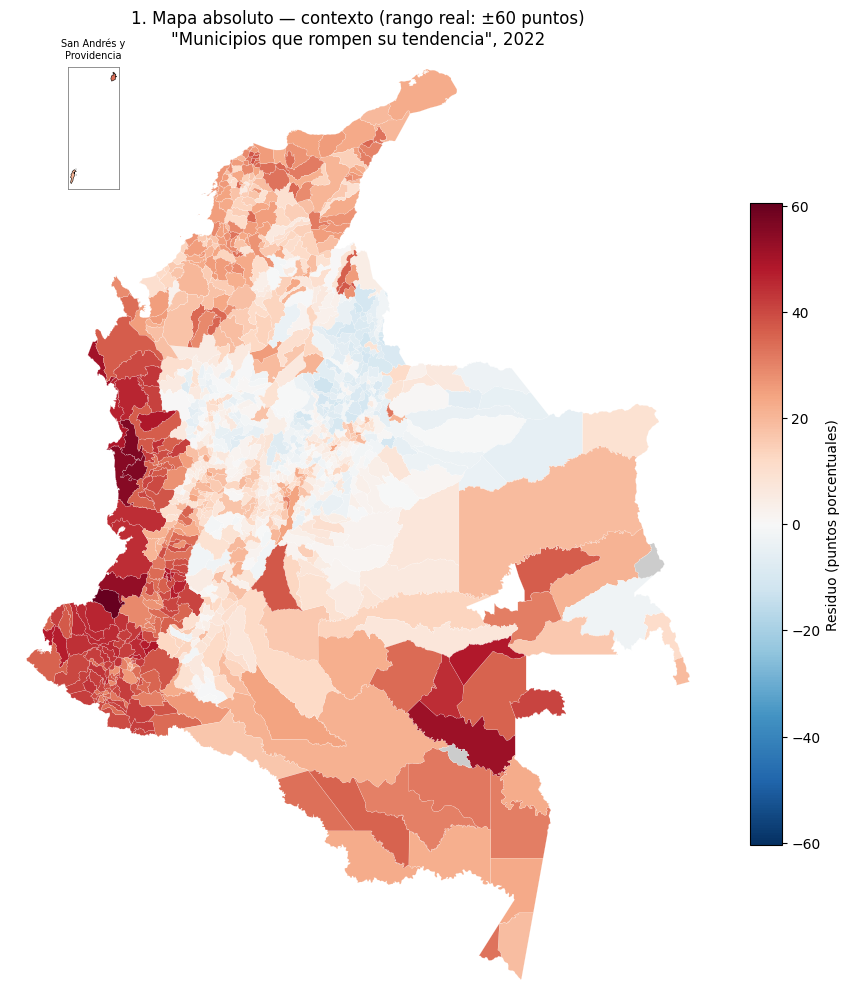


NOTA (pie de figura — memoria y app, texto acordado con los chats de revisión):
"En 2022 hubo una ola nacional hacia la izquierda que el modelo, entrenado con elecciones
 anteriores, no podía anticipar en su magnitud: el 76% de los municipios votó por encima de
 su tendencia previa. El color absoluto refleja en gran parte ese desplazamiento común."

Texto blindado (no reformular): "Los residuos miden la desviación del voto respecto a la
trayectoria histórica del municipio. No son una prueba de irregularidad."


In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

geo_residuos_2022 = geo.merge(t2022, on='divipola', how='left')
print('Municipios en geometria:', len(geo_residuos_2022),
      '| con residuo 2022 asignado:', geo_residuos_2022['residuo'].notna().sum())

# Separar el territorio continental de San Andres/Providencia (dpto 88) para
# recortar el bounding box del mapa principal y dibujar las islas en un inset
continental = geo_residuos_2022[~geo_residuos_2022['divipola'].str.startswith('88')]
islas = geo_residuos_2022[geo_residuos_2022['divipola'].str.startswith('88')]

fig, ax = plt.subplots(figsize=(9, 11))

confiables = continental[continental['baja_confiabilidad_electoral'] == 0]
no_confiables = continental[continental['baja_confiabilidad_electoral'] == 1]

vmax = confiables['residuo'].abs().max()
confiables.plot(
    column='residuo', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
    legend=True, ax=ax, edgecolor='white', linewidth=0.1,
    legend_kwds={'label': 'Residuo (puntos porcentuales)', 'shrink': 0.6}
)
if len(no_confiables) > 0:
    no_confiables.plot(color='#cccccc', ax=ax, edgecolor='white', linewidth=0.1)

# Recortar al bounding box del territorio continental (evita el hueco vacio
# que dejaban las islas al estar lejos del resto)
minx, miny, maxx, maxy = continental.total_bounds
margen = 0.3
ax.set_xlim(minx - margen, maxx + margen)
ax.set_ylim(miny - margen, maxy + margen)

ax.set_title(f'1. Mapa absoluto — contexto (rango real: ±{vmax:.0f} puntos)\n'
             '"Municipios que rompen su tendencia", 2022')
ax.set_axis_off()

# Inset con San Andres y Providencia, misma escala de color que el mapa principal
axins = inset_axes(ax, width='20%', height='13%', loc='upper left', borderpad=1)
islas.plot(column='residuo', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
           ax=axins, edgecolor='black', linewidth=0.4)
axins.set_xticks([])
axins.set_yticks([])
axins.set_title('San Andrés y\nProvidencia', fontsize=7)
for spine in axins.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

print()
print('NOTA (pie de figura — memoria y app, texto acordado con los chats de revisión):')
print('"En 2022 hubo una ola nacional hacia la izquierda que el modelo, entrenado con elecciones')
print(' anteriores, no podía anticipar en su magnitud: el 76% de los municipios votó por encima de')
print(' su tendencia previa. El color absoluto refleja en gran parte ese desplazamiento común."')
print()
print('Texto blindado (no reformular): "Los residuos miden la desviación del voto respecto a la')
print('trayectoria histórica del municipio. No son una prueba de irregularidad."')

### 5.1 Por qué el mapa absoluto no es la figura de referencia

El mapa de arriba, aunque correcto, cuenta **dos historias mezcladas**. Verificado con los datos
reales de la propia tabla (celda siguiente): en 2022 el residuo medio es de +12,6 puntos y el
75,6% de los municipios tienen residuo positivo. Eso significa que el mapa muestra sobre todo algo
que ya sabíamos y que no es un hallazgo nuevo: **en 2022 casi todo el país votó más a la izquierda
de lo que su propia trayectoria predecía**, porque hubo una ola nacional (el ascenso de Gustavo
Petro) que un modelo basado en el pasado de cada municipio no podía anticipar.

Es el mismo **"error de nivel"** ya documentado en Fase 3 (bitácora Fase 3, §3): la validación
temporal pura castiga sobre todo el desplazamiento de nivel nacional del año, no el perfil
particular de cada municipio. Aquí pasa lo mismo con los residuos: la marea roja del mapa absoluto
es, en gran parte, *"todo el país subió"* — no *"estos municipios rompen su tendencia de forma
particular"*. Por eso el mapa absoluto se presenta primero, como **contexto**, y el mapa centrado
de la siguiente sección es la **figura de referencia** del hallazgo territorial.

In [9]:
media_2022 = t2022['residuo'].mean()
pct_positivos_2022 = (t2022['residuo'] > 0).mean() * 100
pct_por_encima_centrado = (t2022['residuo_centrado'] > 0).mean() * 100
pct_por_debajo_centrado = (t2022['residuo_centrado'] < 0).mean() * 100

print(f'Residuo absoluto 2022 - media: {media_2022:.1f} puntos | % positivos: {pct_positivos_2022:.1f}%')
print(f'Residuo centrado 2022  - % por encima de la media: {pct_por_encima_centrado:.1f}% '
      f'| % por debajo: {pct_por_debajo_centrado:.1f}%')
print()
print('El desplazamiento de ~76% -> ~41%/59% al centrar confirma la nota de arriba: la mayor parte')
print('del color rojo del mapa absoluto es la ola nacional, no una desviación territorial específica.')

Residuo absoluto 2022 - media: 12.6 puntos | % positivos: 75.6%
Residuo centrado 2022  - % por encima de la media: 41.5% | % por debajo: 58.5%

El desplazamiento de ~76% -> ~41%/59% al centrar confirma la nota de arriba: la mayor parte
del color rojo del mapa absoluto es la ola nacional, no una desviación territorial específica.


### 5.2 Mapa centrado — la figura de referencia

`residuo_centrado = residuo − media del residuo de ese año` (media calculada solo sobre
municipios `ventana_estable=True` y `baja_confiabilidad_electoral=0`, para que ni la ventana 2010
ni los micro-electorados distorsionen la referencia — columna ya calculada en
`m.calcular_tabla_residuos()`, ver `src/modelo.py`; verificado: la media da exactamente 0, salvo
error de redondeo de punto flotante, en los tres años estables).

Este es el **mapa de referencia** del hallazgo de esta fase: descontada la ola nacional, muestra
qué territorios se movieron más de lo que ya se movía todo el país. El patrón que aparece —
Pacífico y sur por encima de la media, interior andino por debajo— **no es un fenómeno nuevo**:
coincide con la regionalización del voto de izquierda ya identificada en el EDA (Fase 2) y
confirmada en Fase 3 (hallazgo 3: el bloque Pacífico/periferia explica el voto muy por encima de
lo que aporta la pobreza sola). Este mapa no destapa un hallazgo independiente — **confirma con
granularidad municipal** un patrón que el proyecto ya había establecido a nivel departamental/
regional. Sigue sin ser, en ningún caso, prueba de irregularidad — solo un patrón de desviación
relativa, consistente con la regionalización ya demostrada.

/tmp/ipykernel_560/2537736011.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


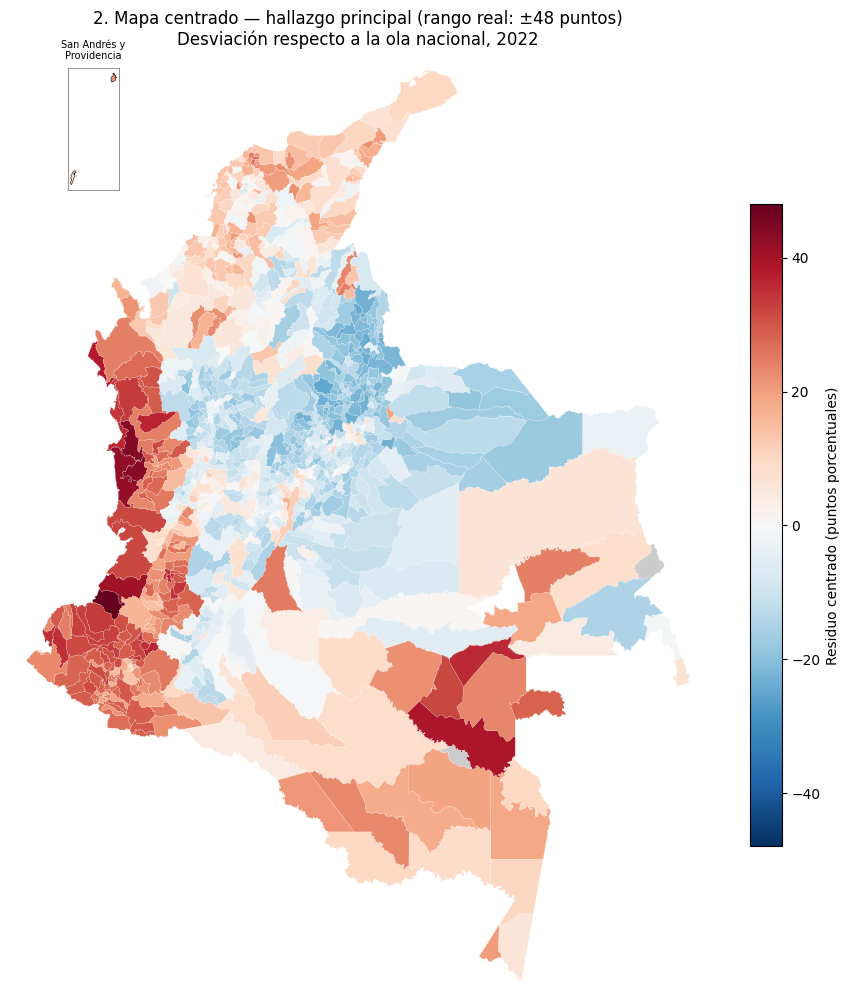

Rango del mapa absoluto: ±60 pts | Rango del mapa centrado: ±48 pts
(escalas independientes, cada una ajustada a su propio rango real — el color no es
 comparable en magnitud absoluta entre los dos mapas, solo el patrón geográfico dentro
 de cada uno; los rangos quedan explícitos en el título de cada figura.)

NOTA (pie de figura — memoria y app, texto acordado con los chats de revisión):
"Una vez descontada la ola nacional, el Pacífico y el sur se movieron por encima de la
 media nacional y el interior andino por debajo. El patrón territorial de la desviación
 coincide con la geografía de la regionalización del voto ya identificada en el EDA: el
 mapa no destapa un fenómeno nuevo, lo confirma con granularidad municipal."


In [10]:
continental_c = geo_residuos_2022[~geo_residuos_2022['divipola'].str.startswith('88')]
islas_c = geo_residuos_2022[geo_residuos_2022['divipola'].str.startswith('88')]

fig2, ax2 = plt.subplots(figsize=(9, 11))

confiables_c = continental_c[continental_c['baja_confiabilidad_electoral'] == 0]
no_confiables_c = continental_c[continental_c['baja_confiabilidad_electoral'] == 1]

vmax_c = confiables_c['residuo_centrado'].abs().max()
confiables_c.plot(
    column='residuo_centrado', cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c,
    legend=True, ax=ax2, edgecolor='white', linewidth=0.1,
    legend_kwds={'label': 'Residuo centrado (puntos porcentuales)', 'shrink': 0.6}
)
if len(no_confiables_c) > 0:
    no_confiables_c.plot(color='#cccccc', ax=ax2, edgecolor='white', linewidth=0.1)

minx, miny, maxx, maxy = continental_c.total_bounds
margen = 0.3
ax2.set_xlim(minx - margen, maxx + margen)
ax2.set_ylim(miny - margen, maxy + margen)

ax2.set_title(f'2. Mapa centrado — hallazgo principal (rango real: ±{vmax_c:.0f} puntos)\n'
              'Desviación respecto a la ola nacional, 2022')
ax2.set_axis_off()

axins2 = inset_axes(ax2, width='20%', height='13%', loc='upper left', borderpad=1)
islas_c.plot(column='residuo_centrado', cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c,
             ax=axins2, edgecolor='black', linewidth=0.4)
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_title('San Andrés y\nProvidencia', fontsize=7)
for spine in axins2.spines.values():
    spine.set_edgecolor('gray')
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

print(f'Rango del mapa absoluto: ±{vmax:.0f} pts | Rango del mapa centrado: ±{vmax_c:.0f} pts')
print('(escalas independientes, cada una ajustada a su propio rango real — el color no es')
print(' comparable en magnitud absoluta entre los dos mapas, solo el patrón geográfico dentro')
print(' de cada uno; los rangos quedan explícitos en el título de cada figura.)')
print()
print('NOTA (pie de figura — memoria y app, texto acordado con los chats de revisión):')
print('"Una vez descontada la ola nacional, el Pacífico y el sur se movieron por encima de la')
print(' media nacional y el interior andino por debajo. El patrón territorial de la desviación')
print(' coincide con la geografía de la regionalización del voto ya identificada en el EDA: el')
print(' mapa no destapa un fenómeno nuevo, lo confirma con granularidad municipal."')

In [11]:
ruta_figura = f'{BASE_DIR}/notebooks/figuras/residuos_04_mapa_2022.png'
fig.savefig(ruta_figura, dpi=150, bbox_inches='tight')
print(f'Figura guardada como candidata reutilizable (memoria): {ruta_figura}')

Figura guardada como candidata reutilizable (memoria): ../notebooks/figuras/residuos_04_mapa_2022.png


In [12]:
ruta_figura_centrada = f'{BASE_DIR}/notebooks/figuras/residuos_04_mapa_centrado_2022.png'
fig2.savefig(ruta_figura_centrada, dpi=150, bbox_inches='tight')
print(f'Figura guardada como candidata reutilizable (memoria): {ruta_figura_centrada}')

Figura guardada como candidata reutilizable (memoria): ../notebooks/figuras/residuos_04_mapa_centrado_2022.png


## 6. RESUMEN EJECUTIVO DE ESTE NOTEBOOK

**Producido:**
- `datos/procesados/tabla_residuos.csv` — 4.487 filas (1 por municipio-año, años 2010/2014/2018/2022
  únicamente), 18 columnas (incluye `residuo_centrado`, añadida tras la revisión del chat de
  validación — ver §5.1/5.2). Residuos calculados out-of-sample con un modelo distinto por año
  (ventana expansiva, mismo criterio de Fase 3).
- `notebooks/figuras/residuos_04_mapa_2022.png` — mapa absoluto, candidato a memoria.
- `notebooks/figuras/residuos_04_mapa_centrado_2022.png` — mapa centrado (desviación respecto a la
  ola nacional), candidato a memoria.

**Las cuatro verificaciones pasaron** (celda 7): 2006 ausente, 2010 marcado `ventana_estable=False`,
cada residuo confirmado out-of-sample (año de entrenamiento máximo < año de test en los 4 casos),
banderas de confiabilidad sin nulos y coherentes con el dataset maestro.

**Hallazgo de la revisión de Opus (§5.1)**: el mapa absoluto de 2022 mezcla dos capas — la ola
nacional (residuo medio +12,6 puntos, 75,6% de municipios positivos, efecto del ascenso de Petro
que el modelo no podía anticipar) y la desviación territorial específica. Al centrar por la media
del año, el reparto pasa a 41,5%/58,5% — el patrón territorial limpio. Por eso la app y la memoria
deben mostrar **dos mapas, no uno**, en orden fijo: absoluto (contexto) → centrado (hallazgo
principal), cada uno con su pie de figura ya redactado y acordado con los dos chats de revisión.

**Ajuste de presentación (última ronda de revisión)**: el mapa centrado se enlaza explícitamente
con el hallazgo de regionalización de Fase 2/Fase 3 (§5.2) — no se presenta como un descubrimiento
independiente, sino como confirmación a nivel municipal de un patrón ya establecido a nivel
departamental. San Andrés y Providencia (departamento 88, geográficamente lejos del resto del
territorio) se muestran en un *inset* en la esquina superior izquierda de cada mapa, con el
bounding box del mapa principal recortado al territorio continental — antes dejaban un hueco vacío
que dañaba la presentación de las figuras estáticas (en la app interactiva con folium no hace
falta, el zoom lo resuelve solo). Los rangos reales de cada escala (±60 el absoluto, ±48 el centrado) quedan explícitos en el título de cada mapa, para que no se confunda la magnitud
entre ambos al mirarlos por separado.

**Decisiones que no se reabren en fases posteriores:**
- El residuo (absoluto o centrado) se interpreta como cambio político genuino, nunca como señal de
  conflicto o irregularidad (Fase 3, hipótesis de coacción refutada con evidencia).
- 2010 permanece en la tabla pero marcado como inestable, y su `residuo_centrado` es `NaN` por
  diseño — quien lo use en un ranking o mapa multi-año debe filtrar `ventana_estable == True`
  primero.
- El ranking de anomalías (top-20, mapas) siempre filtra `baja_confiabilidad_electoral == 0`
  **antes** de ordenar/colorear, nunca después.
- El mapa absoluto siempre se presenta junto a su nota de la ola nacional — nunca solo, para no
  sugerir que el modelo "falló" en años de alto desplazamiento nacional.

**Lo que queda para Chat 7 (Streamlit), no resuelto aquí:**
- Leer `tabla_residuos.csv` directamente — no recalcular los residuos ni `residuo_centrado` dentro
  de la app.
- Página 3: **dos mapas interactivos** (`plotly`/`folium`, no `geopandas` estático) — el absoluto
  ("municipios que rompen su tendencia", con su nota) y el centrado ("desviación respecto a la ola
  nacional"), tal como se construyeron aquí.
- Página 2 (selector de municipio y año): puede usar `tabla_residuos.csv` para 2010/2014/2018/2022;
  para 2006 no hay residuo posible (ver verificación 1) — la página debe manejar ese caso
  explícitamente, no fallar silenciosamente si alguien lo selecciona.